In [1]:
!pip install sentence-transformers scikit-learn pandas numpy


In [2]:
import json
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [3]:
with open("movie_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Loaded {len(df)} movies")
df.head()

Loaded 970 movies


,imdb_url,title,year,runtime,genre,rating,votes,plot
0,https://www.imdb.com/title/tt7229666/,Chhakka Panja 2,2017,138 min,"Comedy, Drama",6.6,290,Chhakka Panja 2 continues with the new story o...
1,https://www.imdb.com/title/tt8393764/,Chhakka Panja 3,2018,145 min,Comedy,6.3,96,When she learns about the worst condition of t...
2,https://www.imdb.com/title/tt7672868/,Intu Mintu Londonma,2018,120 min,Romance,7.3,71,When Ishan (Dhiraj Magar) and Meera (Samragyee...
3,https://www.imdb.com/title/tt10942220/,Kabaddi Kabaddi Kabaddi,2019,115 min,"Comedy, Drama, Romance",8.6,9,A heartbroken man falls in love with a woman w...
4,https://www.imdb.com/title/tt8387542/,Captain,2019,135 min,"Drama, Sport",3.2,46,Father's dedication to guiding his son to beco...


In [4]:
for col in df.columns:
    empty_mask = df[col].isna() | df[col].astype(str).str.strip().eq("")
    if col == "plot":
        empty_mask = empty_mask | df[col].astype(str).str.strip().eq("Add a Plot")
    print(f"{col:12s}: {empty_mask.sum()} missing/empty")

imdb_url    : 0 missing/empty
title       : 0 missing/empty
year        : 27 missing/empty
runtime     : 0 missing/empty
genre       : 0 missing/empty
rating      : 0 missing/empty
votes       : 0 missing/empty
plot        : 3 missing/empty


In [5]:
df["plot"] = df["plot"].astype(str).str.strip()
df.loc[df["plot"].isin(["Add a Plot", "nan", ""]), "plot"] = ""

df["genre"] = df["genre"].astype(str).str.strip()
df.loc[df["genre"].isin(["nan", ""]), "genre"] = "Unknown"

df["year"] = df["year"].astype(str).str.strip()
df.loc[df["year"].isin(["nan", ""]), "year"] = "Unknown"

# Drop rows with zero content signal (no genre AND no plot)
before = len(df)
df = df[~((df["genre"] == "Unknown") & (df["plot"] == ""))].reset_index(drop=True)
print(f"Dropped {before - len(df)} movies. Remaining: {len(df)}")

Dropped 0 movies. Remaining: 970


In [6]:
df["combined_features"] = (
    "Genre: " + df["genre"] + ". " + "Genre: " + df["genre"] + ". " +
    "Plot: " + df["plot"]
).str.strip()

df["combined_features"].iloc[0]

'Genre: Comedy, Drama. Genre: Comedy, Drama. Plot: Chhakka Panja 2 continues with the new story of Raja and his friend at the village.'

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\asus\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asus\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
embeddings = model.encode(
    df["combined_features"].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
embeddings.shape

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

(970, 384)

In [9]:
sim_matrix = cosine_similarity(embeddings)
sim_matrix.shape

(970, 970)

In [10]:
title_to_index = {
    title.strip().lower(): idx
    for idx, title in enumerate(df["title"])
}
len(title_to_index)

967

In [11]:
def recommend(title, top_n=10):
    key = title.strip().lower()
    if key not in title_to_index:
        matches = [t for t in title_to_index if key in t]
        if not matches:
            return f"'{title}' not found. Use search_movies() first."
        key = matches[0]

    idx = title_to_index[key]
    sims = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
    sims = [s for s in sims if s[0] != idx][:top_n]

    result = df.iloc[[i for i, _ in sims]][["title", "year", "genre", "rating"]].copy()
    result["similarity"] = [round(float(s), 4) for _, s in sims]
    return result.reset_index(drop=True)

In [13]:
recommend("Chhakka Panja 2", top_n=5)

,title,year,genre,rating,similarity
0,Chhakka Panja,2016,"Comedy, Drama, Family",6.8,0.7266
1,Mahajatra,2024,"Family, Comedy, Crime, Drama",0,0.7121
2,Kumva Karan,2018,Drama,null,0.6877
3,Dui Duna Pannch,2012,Comedy,null,0.6874
4,Kabaddi Kabaddi,2015,"Comedy, Drama",7.9,0.6757


In [14]:
def search_movies(query, limit=15):
    query = query.strip().lower()
    matches = df[df["title"].str.lower().str.contains(query, na=False)]
    return matches[["title", "year", "genre", "rating"]].head(limit).reset_index(drop=True)

search_movies("Chhakka")

,title,year,genre,rating
0,Chhakka Panja 2,2017,"Comedy, Drama",6.6
1,Chhakka Panja 3,2018,Comedy,6.3
2,Chhakka Panja,2016,"Comedy, Drama, Family",6.8
3,Chhakka Panja 4,2023,Comedy,0


In [15]:
with open("movie_embeddings.pkl", "wb") as f:
    pickle.dump({
        "df": df,
        "embeddings": embeddings,
        "sim_matrix": sim_matrix,
        "title_to_index": title_to_index,
    }, f)
print("Saved.")

Saved.


In [16]:
def precision_recall_at_k(k=10, sample_size=100, seed=42):
    rng = np.random.default_rng(seed)
    n = len(df)
    sample_idxs = rng.choice(n, size=min(sample_size, n), replace=False)
    genre_sets = df["genre"].apply(lambda g: set(x.strip().lower() for x in g.split(",")))
    precisions, recalls = [], []
    for idx in sample_idxs:
        query_genres = genre_sets.iloc[idx]
        relevant = {j for j in range(n) if j != idx and genre_sets.iloc[j] & query_genres}
        if not relevant:
            continue
        sims = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
        top_k = [i for i, _ in sims if i != idx][:k]
        hits = len(set(top_k) & relevant)
        precisions.append(hits / k)
        recalls.append(hits / min(len(relevant), k))
    print(f"Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Recall@{k}:    {np.mean(recalls):.4f}")

precision_recall_at_k(k=5)

Precision@5: 0.8742
Recall@5:    0.8866


In [17]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [23]:
# Inspect: compare two specific movies' plots and their computed similarity
movie_a = "Chhakka Panja 2"
movie_b = "Chhakka Panja"

idx_a = title_to_index[movie_a.lower()]
idx_b = title_to_index[movie_b.lower()]

print("Movie A:", df.iloc[idx_a]["title"], "-", df.iloc[idx_a]["plot"][:150])
print()
print("Movie B:", df.iloc[idx_b]["title"], "-", df.iloc[idx_b]["plot"][:150])
print()
print("Cosine similarity:", sim_matrix[idx_a][idx_b])

Movie A: Chhakka Panja 2 - Chhakka Panja 2 continues with the new story of Raja and his friend at the village. 

Movie B: Chhakka Panja - Story of five friends Raja (Deepak Raj Giri), Saraswoti (Jeetu Nepal), Magne (Kedar Ghimire) and Buddhi (Buddhi Tamang). Raja is rich but illiterate a

Cosine similarity: 0.726576


Chhakka Panja 2 vs Chhakka Panja: 0.7266
Kabaddi Kabaddi Kabaddi vs Kabaddi: 0.5822
Loot vs Loot 2: 0.7008


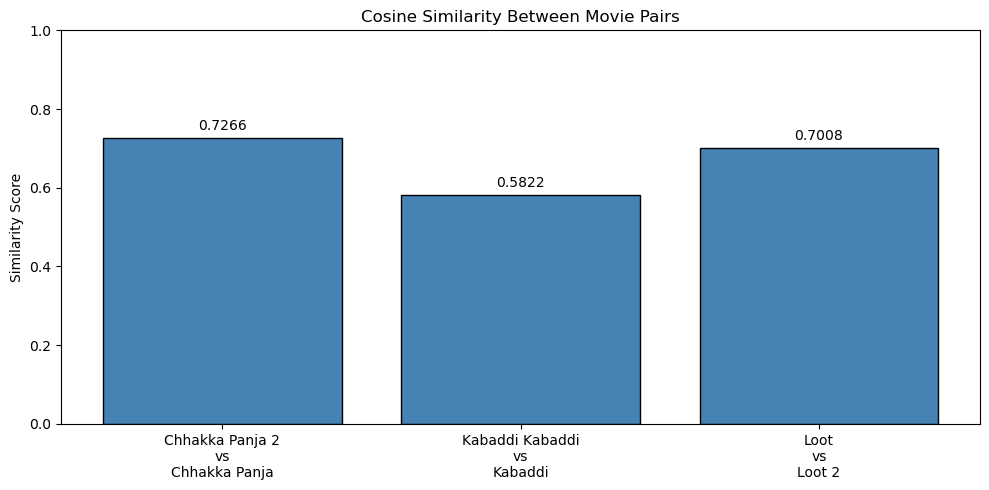

✅ Plot Similarity Inspection Done!


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compare multiple movie pairs
pairs = [
    ("Chhakka Panja 2", "Chhakka Panja"),
    ("Kabaddi Kabaddi Kabaddi", "Kabaddi"),
    ("Loot", "Loot 2")
]

pair_labels = []
pair_scores = []

for movie_a, movie_b in pairs:
    try:
        idx_a = title_to_index[movie_a.lower()]
        idx_b = title_to_index[movie_b.lower()]
        score = sim_matrix[idx_a][idx_b]
        pair_labels.append(f"{movie_a[:15]}\nvs\n{movie_b[:15]}")
        pair_scores.append(round(score, 4))
        print(f"{movie_a} vs {movie_b}: {score:.4f}")
    except:
        print(f"Movie not found!")

# Plot similarity scores
plt.figure(figsize=(10, 5))
bars = plt.bar(pair_labels, pair_scores, 
               color='steelblue', edgecolor='black')
plt.ylabel('Similarity Score')
plt.title('Cosine Similarity Between Movie Pairs')
plt.ylim(0, 1)
for bar, score in zip(bars, pair_scores):
    plt.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 0.02,
             f'{score:.4f}', ha='center')
plt.tight_layout()
plt.show()

print("✅ Plot Similarity Inspection Done!")